In [1]:
import os
import sys
import json
from pathlib import Path

import cloudpickle
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT:', PROJECT_ROOT)


PROJECT_ROOT: /usr/project/xtmp/ds541/td-avar-explore/deep


In [5]:
# save_dir = 'results/cov_dual_lstd/fourrooms_truev_cnn_20260210_135121/FourRoomsCustom-v0'
# save_dir = 'results/cov_dual_lstd/fourrooms_truev_cnn_20260210_142320/FourRoomsCustom-v0'
# save_dir = 'results/cov_dual_lstd/fourrooms_truev_cnn_20260210_145616/FourRoomsCustom-v0'
save_dir = "results/cov_dual_lstd/20260210_161744/FourRooms-misc"


In [6]:
save_dir = Path(save_dir)
if not save_dir.is_absolute():
    save_dir = PROJECT_ROOT / save_dir

config_path = save_dir / 'config.json'
metrics_path = save_dir / 'out.pkl'

if not config_path.exists():
    raise FileNotFoundError(f'Missing config file: {config_path}')
if not metrics_path.exists():
    raise FileNotFoundError(f'Missing metrics file: {metrics_path}')

with open(config_path, 'r') as f:
    config = json.load(f)
with open(metrics_path, 'rb') as f:
    raw = cloudpickle.load(f)

# Support both schemas:
# - raw is already a metrics dict
# - raw is a container like {'metrics': ..., ...}
if isinstance(raw, dict) and 'metrics' in raw and isinstance(raw['metrics'], dict):
    metrics = raw['metrics']
elif isinstance(raw, dict):
    metrics = raw
else:
    raise TypeError(f'Expected dict-like out.pkl, got {type(raw)}')

def _to_numpy_safe(x):
    try:
        arr = np.asarray(x)
        # Keep ragged/object data as-is; plotting cells only use regular numeric tensors.
        if arr.dtype == object:
            return x
        return arr
    except Exception:
        if isinstance(x, dict):
            return {k: _to_numpy_safe(v) for k, v in x.items()}
        if isinstance(x, (list, tuple)):
            return [_to_numpy_safe(v) for v in x]
        return x

metrics = {k: _to_numpy_safe(v) for k, v in metrics.items()}
steps_per_update = int(config['NUM_ENVS']) * int(config['NUM_STEPS'])



def _fourrooms_free_mask(size):

    free = np.ones((size, size), dtype=bool)

    free[0, :] = False

    free[-1, :] = False

    free[:, 0] = False

    free[:, -1] = False



    mid = size // 2

    free[mid, :] = False

    free[:, mid] = False



    q1 = mid // 2

    q3 = mid + (size - mid) // 2

    free[mid, q1] = True

    free[mid, q3] = True

    free[q1, mid] = True

    free[q3, mid] = True

    return free



def _infer_grid_shape(metrics_dict):

    for key in ['visitation_count', 'ri_grid', 'v_e', 'v_i', 'v_e_pred', 'vi_pred']:

        if key not in metrics_dict:

            continue

        arr = np.asarray(metrics_dict[key])

        if arr.ndim >= 3:

            return tuple(arr.shape[-2:])

    return None



def _build_wall_mask(config_dict, metrics_dict):

    env_name = str(config_dict.get('ENV_NAME', ''))

    if env_name not in {'FourRooms-misc', 'FourRoomsCustom-v0'}:

        return None



    shape = _infer_grid_shape(metrics_dict)

    if shape is None or len(shape) != 2 or shape[0] != shape[1]:

        return None



    size = int(shape[0])

    if size < 7 or size % 2 == 0:

        return None



    return ~_fourrooms_free_mask(size)



WALL_MASK = _build_wall_mask(config, metrics)



def imshow_with_walls(ax, grid, cmap='viridis', wall_color='#303030'):

    grid = np.asarray(grid)

    cmap_obj = plt.get_cmap(cmap).copy()



    if WALL_MASK is not None and grid.ndim == 2 and WALL_MASK.shape == grid.shape:

        masked = np.ma.array(grid, mask=WALL_MASK)

        cmap_obj.set_bad(color=wall_color)

        return ax.imshow(masked, cmap=cmap_obj)



    return ax.imshow(grid, cmap=cmap_obj)


print('Loaded run from:', save_dir)
print('steps_per_update:', steps_per_update)
print('metrics keys:', sorted(metrics.keys()))
for k in ['returned_episode_returns', 'returned_discounted_episode_returns', 'mean_rew', 'intrinsic_rew_mean', 'visitation_count']:
    if k in metrics:
        print(f'{k} shape:', np.asarray(metrics[k]).shape)


Loaded run from: /usr/project/xtmp/ds541/td-avar-explore/deep/results/cov_dual_lstd/20260210_161744/FourRooms-misc
steps_per_update: 8192
metrics keys: ['beta', 'bonus_max', 'bonus_mean', 'bonus_std', 'discount', 'e_value_error', 'effective_visits', 'feat_norm', 'i_value_error', 'intrinsic_rew_mean', 'intrinsic_rew_std', 'lambda_ret_mean', 'lambda_ret_std', 'lambda_s', 'lambda_s_max', 'lambda_s_min', 'mean_rew', 'ppo_loss', 'returned_discounted_episode_returns', 'returned_episode', 'returned_episode_lengths', 'returned_episode_returns', 'ri_grid', 'rnd_loss', 'v_e', 'v_e_pred', 'v_i', 'v_i_pred', 'vi_pred', 'visitation_count']
returned_episode_returns shape: (8, 12)
returned_discounted_episode_returns shape: (8, 12)
mean_rew shape: (8, 12)
intrinsic_rew_mean shape: (8, 12)
visitation_count shape: (8, 12, 13, 13)


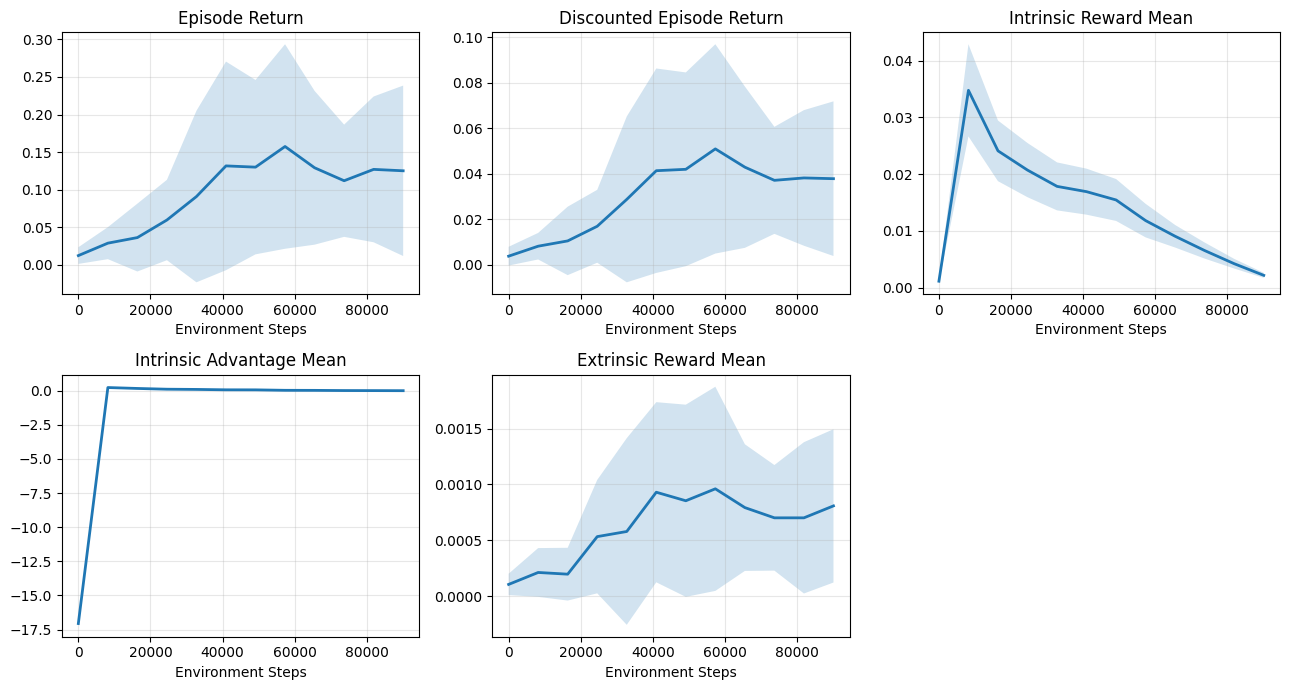

In [7]:

def mean_std(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr, np.zeros_like(arr)
    return arr.mean(axis=0), arr.std(axis=0)

n_updates = None
for key in ['returned_episode_returns', 'returned_discounted_episode_returns', 'mean_rew', 'intrinsic_rew_mean', 'bonus_mean']:
    if key in metrics:
        arr = np.asarray(metrics[key])
        n_updates = arr.shape[1] if arr.ndim >= 2 else arr.shape[0]
        break

if n_updates is None:
    raise KeyError('Could not infer update axis from metrics. Available keys: ' + ', '.join(sorted(metrics.keys())))

x = np.arange(n_updates) * steps_per_update

plot_specs = [
    ('returned_episode_returns', 'Episode Return'),
    ('returned_discounted_episode_returns', 'Discounted Episode Return'),
    ('intrinsic_rew_mean', 'Intrinsic Reward Mean'),
    ('bonus_mean', 'Intrinsic Advantage Mean'),
    ('mean_rew', 'Extrinsic Reward Mean'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, (key, title) in zip(axes, plot_specs):
    if key not in metrics:
        ax.set_visible(False)
        continue
    m, s = mean_std(metrics[key])
    ax.plot(x[:len(m)], m, lw=2)
    if len(s) == len(m):
        ax.fill_between(x[:len(m)], m - s, m + s, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('Environment Steps')
    ax.grid(True, alpha=0.3)

for i in range(len(plot_specs), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


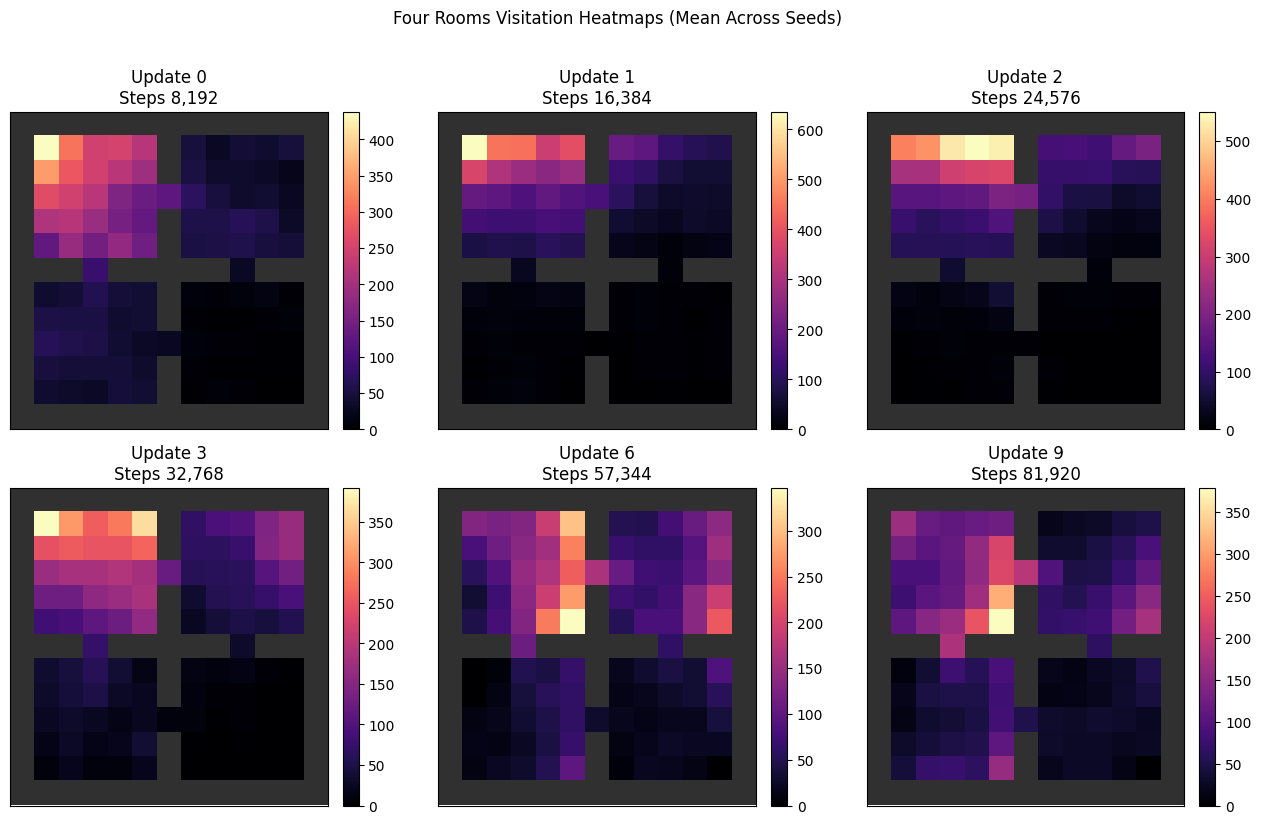

In [26]:
if 'visitation_count' not in metrics:
    raise ValueError('visitation_count not found in metrics. Ensure Four Rooms logging is enabled.')

visit = np.asarray(metrics['visitation_count'])[0]  # (updates, H, W)
n_updates = visit.shape[0]
checkpoints = [c for c in sorted(set([0, 1, 2, 3, n_updates // 8, n_updates // 4, n_updates // 2, (3 * n_updates) // 4, n_updates - 1])) if 0 <= c < n_updates]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, t in zip(axes, checkpoints):
    im = imshow_with_walls(ax, visit[t], cmap='magma')
    ax.set_title(f'Update {t}\nSteps {(t + 1) * steps_per_update:,}')
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(checkpoints), len(axes)):
    axes[i].axis('off')

plt.suptitle('Four Rooms Visitation Heatmaps (Mean Across Seeds)', y=1.02)
plt.tight_layout()
plt.show()

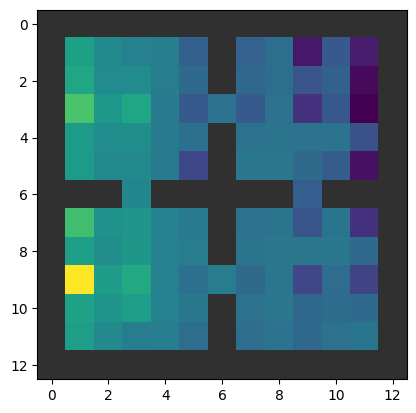

In [27]:
fig, axes = plt.subplots(1,1)
imshow_with_walls(axes, metrics['ri_grid'][0][9] - metrics['ri_grid'][0][0])

(12, 13, 13)


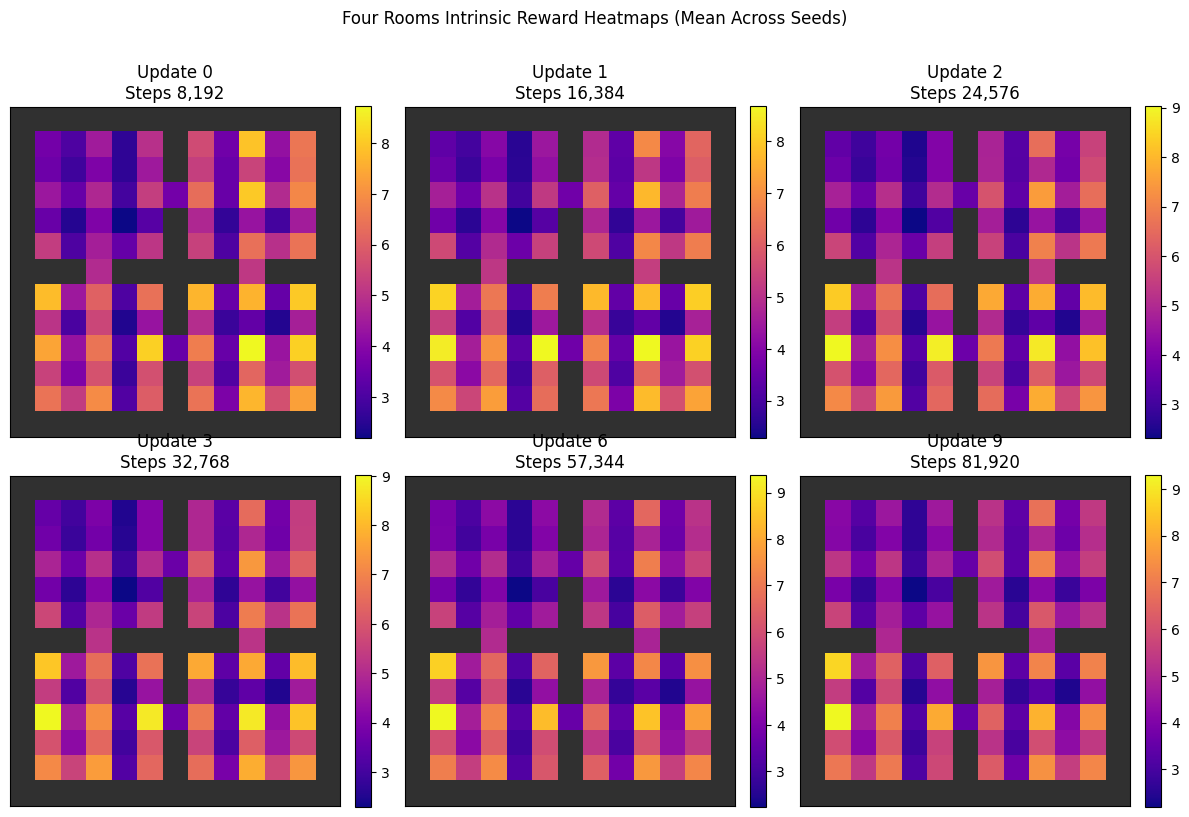

In [15]:
ri = np.asarray(metrics['ri_grid'])[0]  # (updates, H, W)
print(ri.shape)
n_updates = ri.shape[0]
checkpoints = [c for c in sorted(set([0, 1, 2, 3, n_updates // 8, n_updates // 4, n_updates // 2, (3 * n_updates) // 4, n_updates - 1])) if 0 <= c < n_updates]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, t in zip(axes, checkpoints):
    im = imshow_with_walls(ax, ri[t], cmap='plasma')
    ax.set_title(f'Update {t}\nSteps {(t + 1) * steps_per_update:,}')
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(checkpoints), len(axes)):
    axes[i].axis('off')

plt.suptitle('Four Rooms Intrinsic Reward Heatmaps (Mean Across Seeds)', y=1.02)
plt.tight_layout()
plt.show()


In [76]:
print(ve_true.shape[0])

15


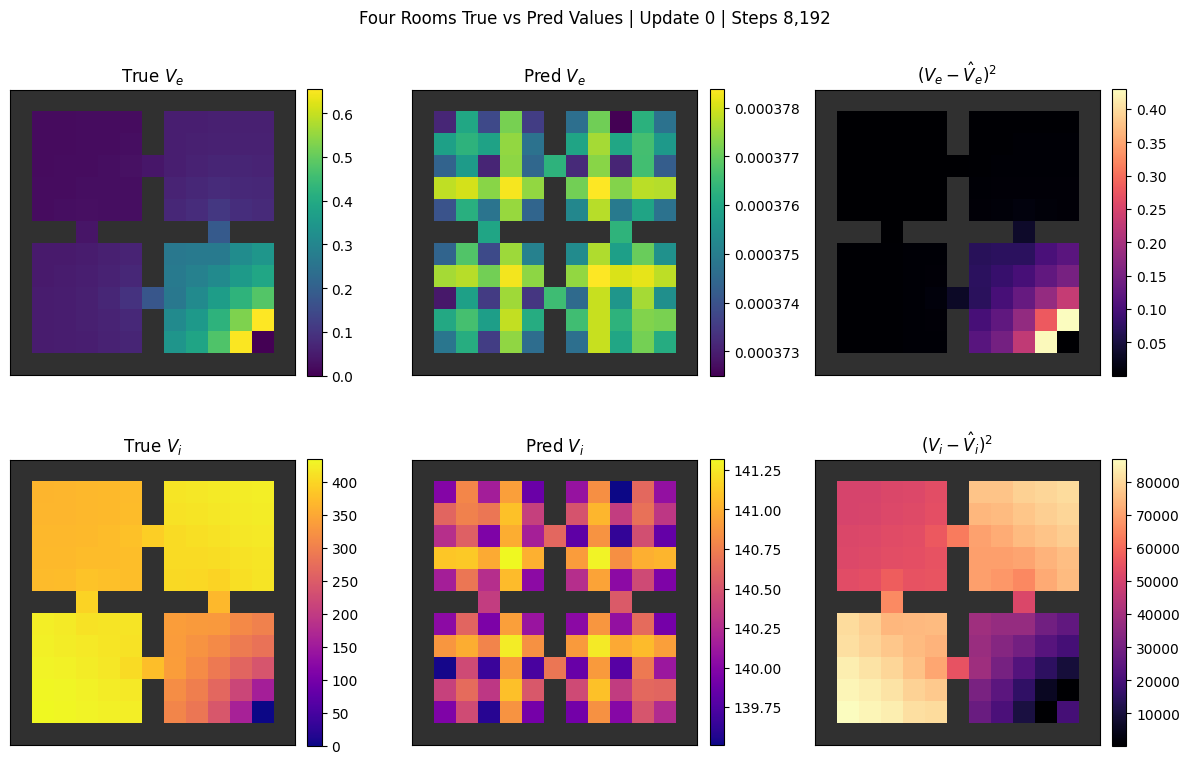

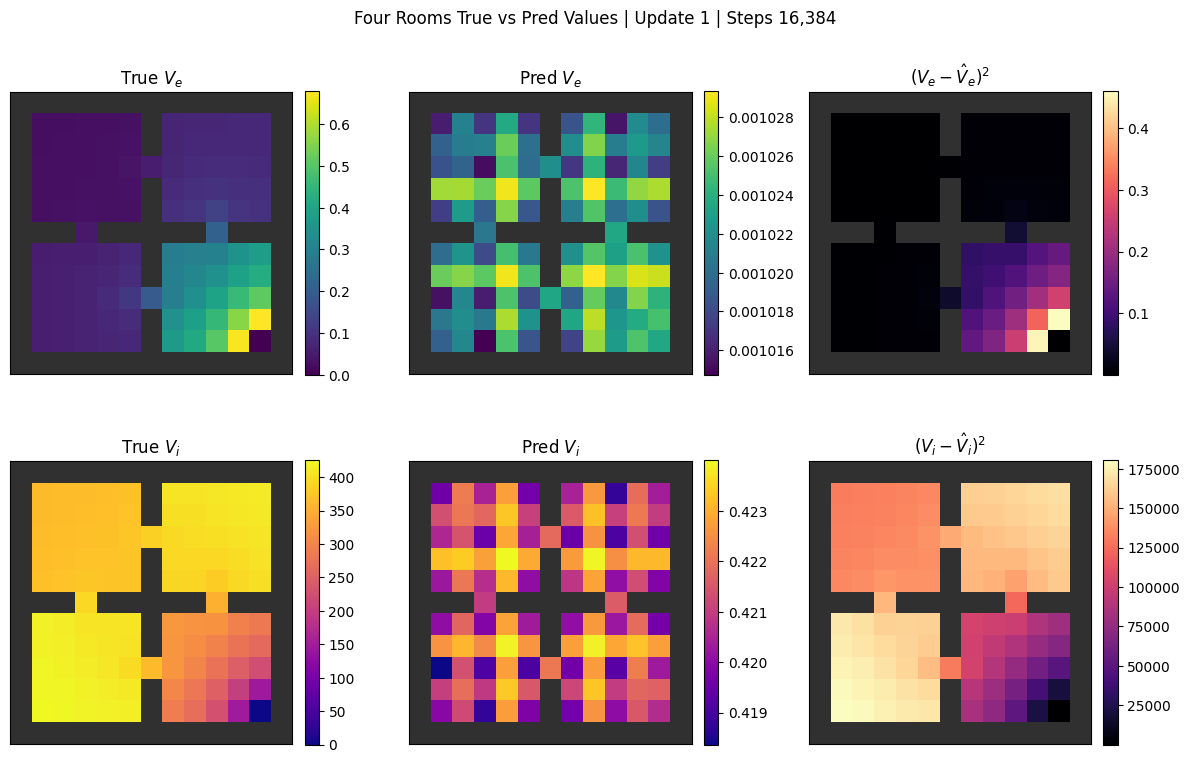

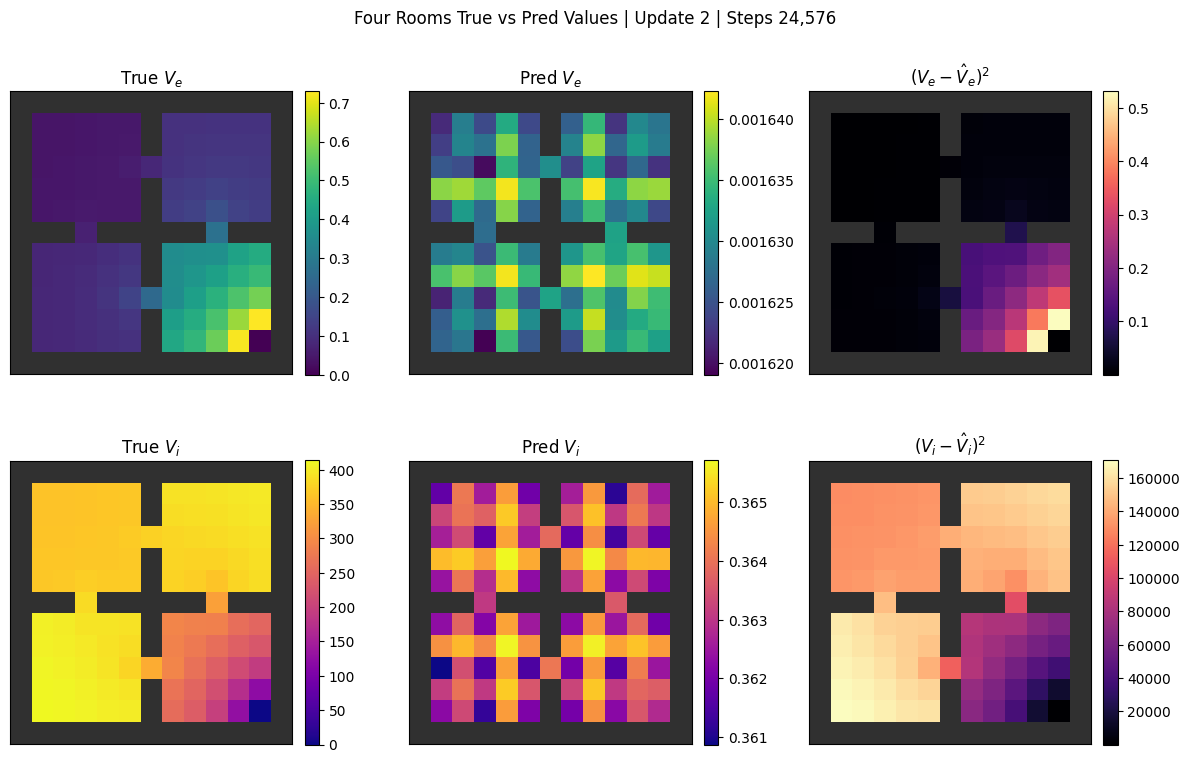

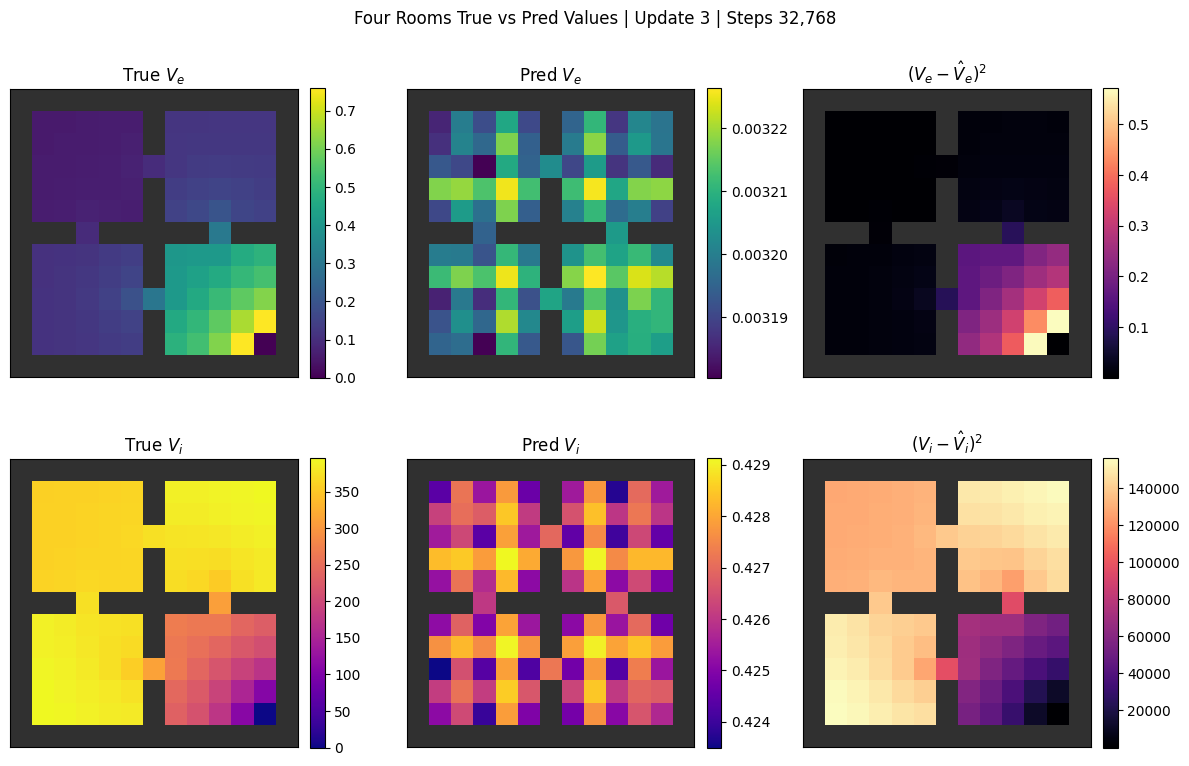

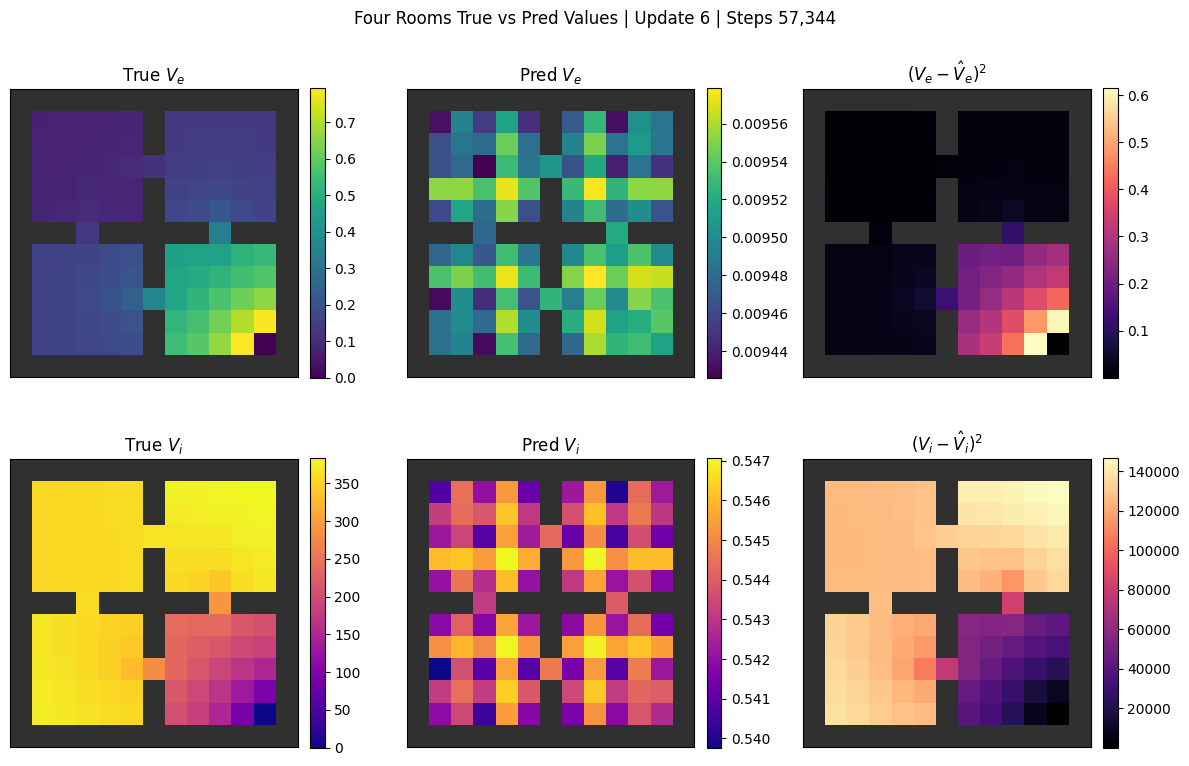

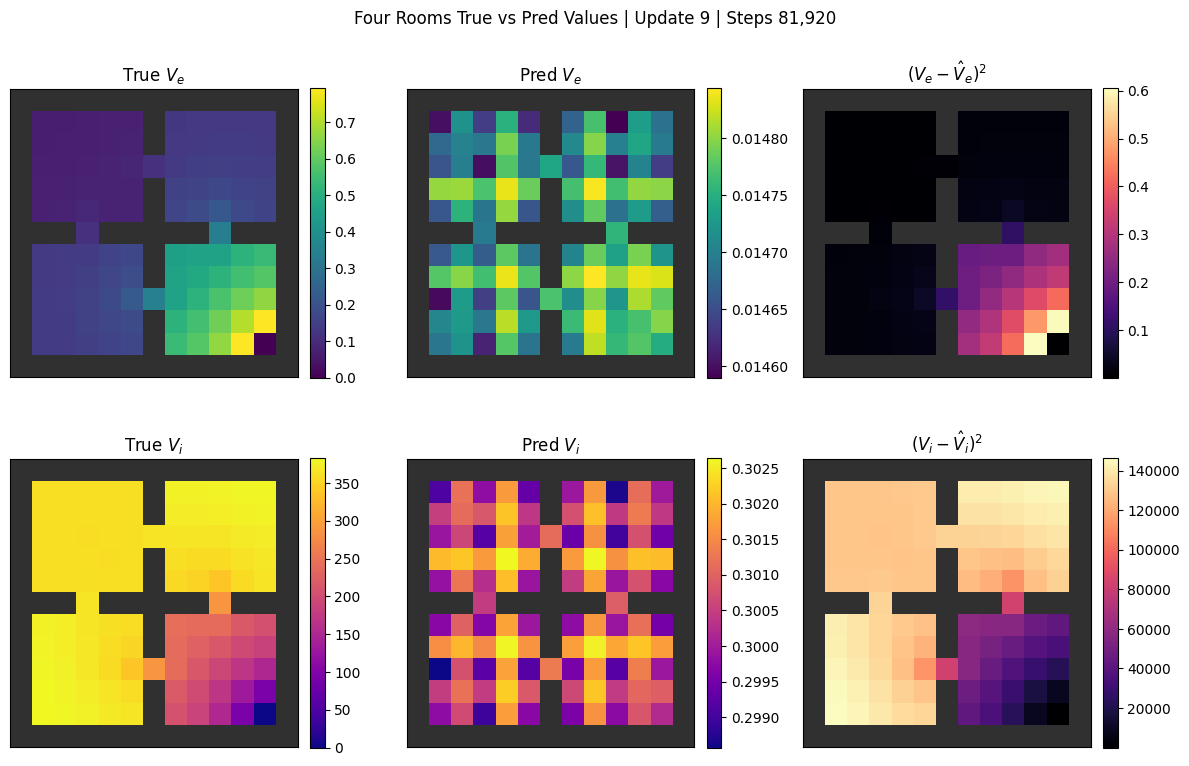

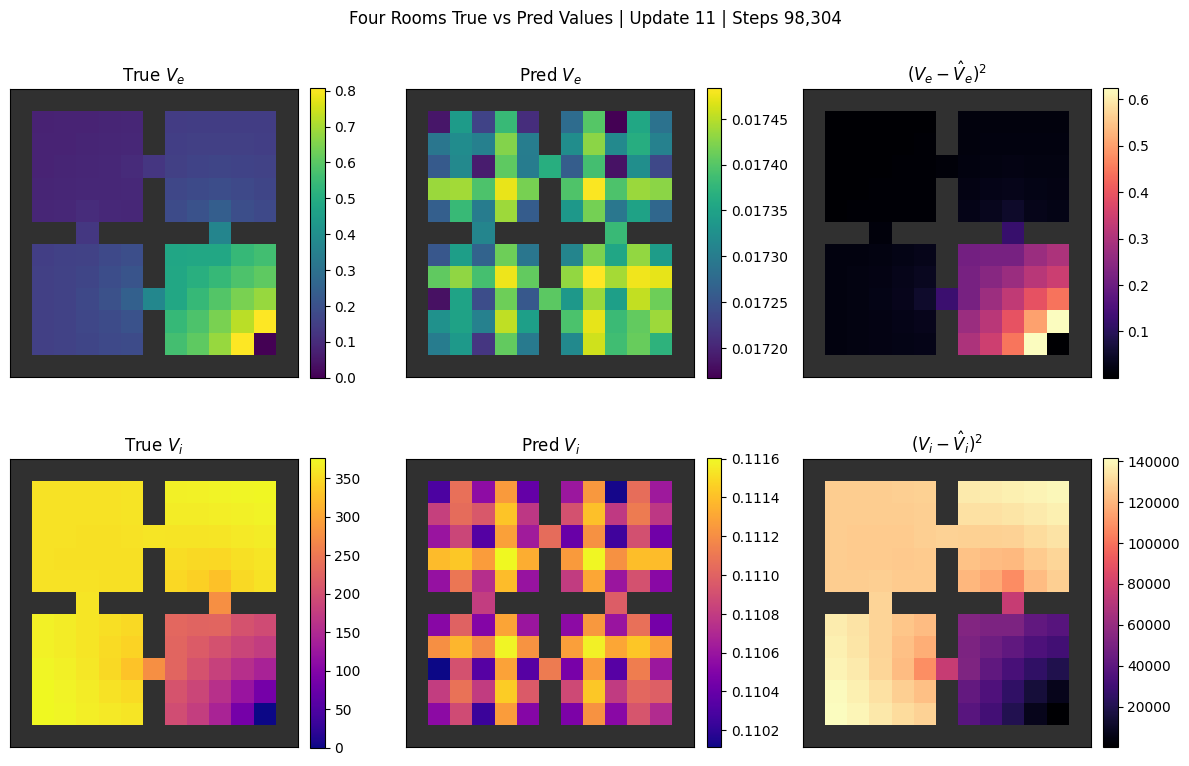

In [16]:
required = ['v_e', 'v_i', 'v_e_pred', 'vi_pred']
if all(k in metrics for k in required):
    ve_true = np.asarray(metrics['v_e']).mean(axis=0)
    vi_true = np.asarray(metrics['v_i']).mean(axis=0)
    ve_pred = np.asarray(metrics['v_e_pred']).mean(axis=0)
    vi_pred = np.asarray(metrics['vi_pred']).mean(axis=0)

    n_updates = ve_true.shape[0]
    checkpoints = [c for c in sorted(set([0, 1, 2, 3, n_updates // 8, n_updates // 4, n_updates // 2, (3 * n_updates) // 4, n_updates - 1])) if 0 <= c < n_updates]

    for t in checkpoints:
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        im0 = imshow_with_walls(axes[0, 0], ve_true[t], cmap='viridis')
        axes[0, 0].set_title('True $V_e$')
        fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

        im1 = imshow_with_walls(axes[0, 1], ve_pred[t], cmap='viridis')
        axes[0, 1].set_title('Pred $V_e$')
        fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

        im2 = imshow_with_walls(axes[0, 2], (ve_true[t] - ve_pred[t])**2, cmap='magma')
        axes[0, 2].set_title('$(V_e - \hat V_e)^2$')
        fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

        im3 = imshow_with_walls(axes[1, 0], vi_true[t], cmap='plasma')
        axes[1, 0].set_title('True $V_i$')
        fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

        im4 = imshow_with_walls(axes[1, 1], vi_pred[t], cmap='plasma')
        axes[1, 1].set_title('Pred $V_i$')
        fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

        im5 = imshow_with_walls(axes[1, 2], (vi_true[t] - vi_pred[t])**2, cmap='magma')
        axes[1, 2].set_title('$(V_i - \hat V_i)^2$')
        fig.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

        for ax in axes.flatten():
            ax.set_xticks([])
            ax.set_yticks([])

        fig.suptitle(f'Four Rooms True vs Pred Values | Update {t} | Steps {(t + 1) * steps_per_update:,}')
        plt.tight_layout()
        plt.show()
else:
    print('True-value grids not found. Set CALC_TRUE_VALUES=True and rerun training.')
